# Phase 6 — Correction du numéraire MAD/USD

**Question de soutenance :** pourquoi la correction de devise a-t-elle changé
la conclusion du projet ?

Ce notebook explique la correction sans relancer le pipeline. Les performances
viennent exclusivement des artefacts Gold du release. La courbe du taux de change
lit le Bronze officiel BAM versionné par DVC, car cette série source n'est pas
dupliquée dans Gold.

## Sources et règles de lecture

- `currency_manifest.json` : politique de numéraire et contrôle qualité.
- `dashboard_showcase.json` : résultats finaux publiés.
- `bam_fx_reference.parquet` : observations officielles BAM, lecture seule.
- `snapshot_manifest.json` : provenance du release.

Les deux univers ne sont jamais agrégés : `full_2021` est en MAD non couvert,
tandis que `etf_2017` reste en USD. Leurs niveaux de Sharpe ne constituent donc
pas une comparaison directe entre univers.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

**Snapshot canonique :** `ae87f48207d1`  — généré le `2026-08-09T02:32:55.411586+00:00` — arbre source propre.

In [2]:
currency = load_json("currency_manifest.json")
showcase = load_json("dashboard_showcase.json")

policy_rows = []
for universe, meta in currency["universes"].items():
    policy = meta["policy"]
    policy_rows.append({
        "univers": universe,
        "numéraire": meta["base_currency"],
        "conversion requise": policy["requires_conversion"],
        "série FX requise": policy["requires_fx"],
        "statut de couverture": meta["hedge_status"],
        "actifs étrangers": len(policy["assets_foreign"]),
        "actifs domestiques": len(policy["assets_domestic"]),
    })
policy_table = pd.DataFrame(policy_rows).set_index("univers")
display(policy_table)

assert policy_table.loc["full_2021", "numéraire"] == "MAD"
assert policy_table.loc["etf_2017", "numéraire"] == "USD"
assert policy_table.loc["full_2021", "conversion requise"]
assert not policy_table.loc["etf_2017", "conversion requise"]

,numéraire,conversion requise,série FX requise,statut de couverture,actifs étrangers,actifs domestiques
univers,,,,,,
full_2021,MAD,True,True,unhedged,5,4
etf_2017,USD,False,False,not applicable — single-currency universe,5,0


## Série officielle et contrôle qualité

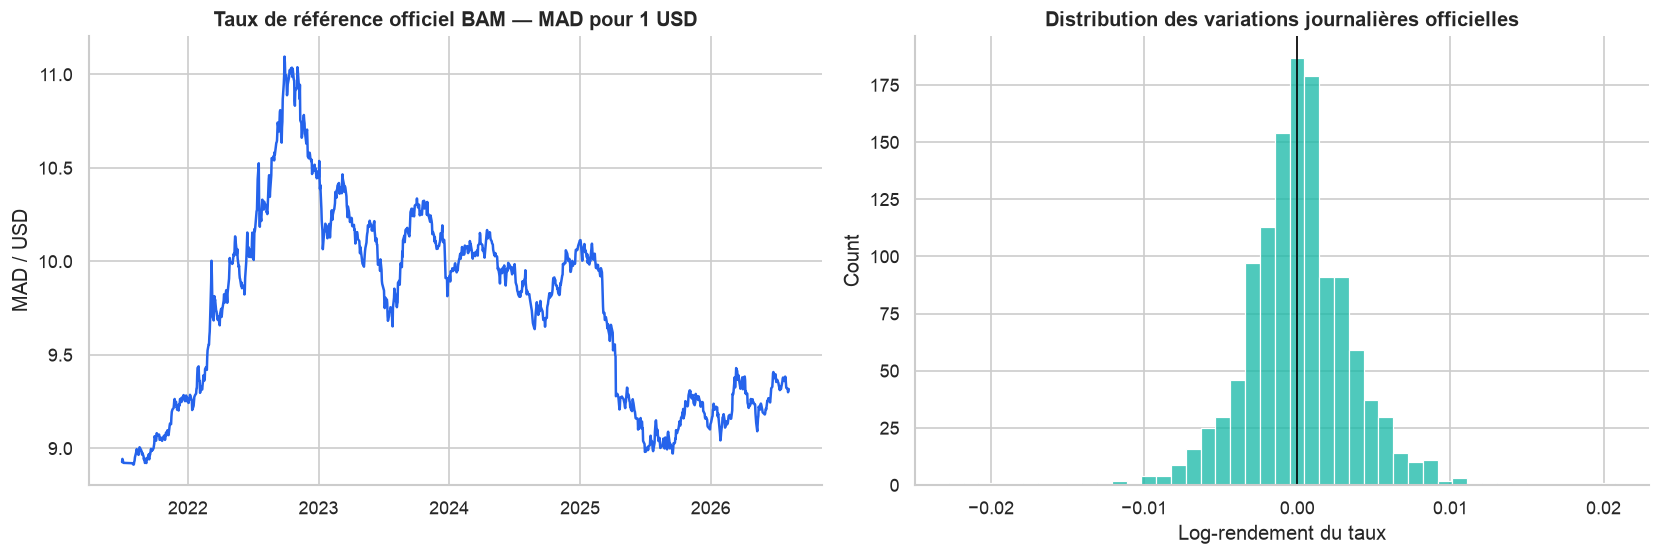

,contrôle,mesure,seuil,règle,verdict
0,Volatilité annualisée,0.0557,0.1500,≤,True
1,Autocorrélation retard 1,0.1244,-0.2500,≥,True
2,Part de valeurs aberrantes,0.0000,0.0010,≤,True
3,Densité d'observation,0.9316,0.9000,≥,True


In [3]:
fx = pd.read_parquet(BRONZE / "bam_fx_reference.parquet").sort_index()
fx.index = pd.to_datetime(fx.index)
quality = currency["universes"]["full_2021"]["fx_quality"]
thresholds = quality["thresholds"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(fx.index, fx["USDMAD"], color="#2563eb", lw=1.5)
axes[0].set_title("Taux de référence officiel BAM — MAD pour 1 USD")
axes[0].set_ylabel("MAD / USD")
axes[0].set_xlabel("")

fx_log_return = np.log(fx["USDMAD"] / fx["USDMAD"].shift(1)).dropna()
sns.histplot(fx_log_return, bins=45, ax=axes[1], color="#14b8a6")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Distribution des variations journalières officielles")
axes[1].set_xlabel("Log-rendement du taux")
plt.tight_layout()
plt.show()

quality_table = pd.DataFrame(
    [
        {
            "contrôle": "Volatilité annualisée",
            "mesure": quality["annualised_volatility"],
            "seuil": thresholds["max_annualised_volatility"],
            "règle": "≤",
        },
        {
            "contrôle": "Autocorrélation retard 1",
            "mesure": quality["lag1_autocorrelation"],
            "seuil": thresholds["min_lag1_autocorrelation"],
            "règle": "≥",
        },
        {
            "contrôle": "Part de valeurs aberrantes",
            "mesure": quality["outlier_share"],
            "seuil": thresholds["max_outlier_share"],
            "règle": "≤",
        },
        {
            "contrôle": "Densité d'observation",
            "mesure": quality["observation_density"],
            "seuil": thresholds["min_observation_density"],
            "règle": "≥",
        },
    ]
)
quality_table["verdict"] = [
    m <= s if rule == "≤" else m >= s
    for m, s, rule in quality_table[["mesure", "seuil", "règle"]].itertuples(index=False)
]
display(quality_table.style.format({"mesure": "{:.4f}", "seuil": "{:.4f}"}))
assert quality["passed"] and quality_table["verdict"].all()

## Effet sur la comparaison publiée

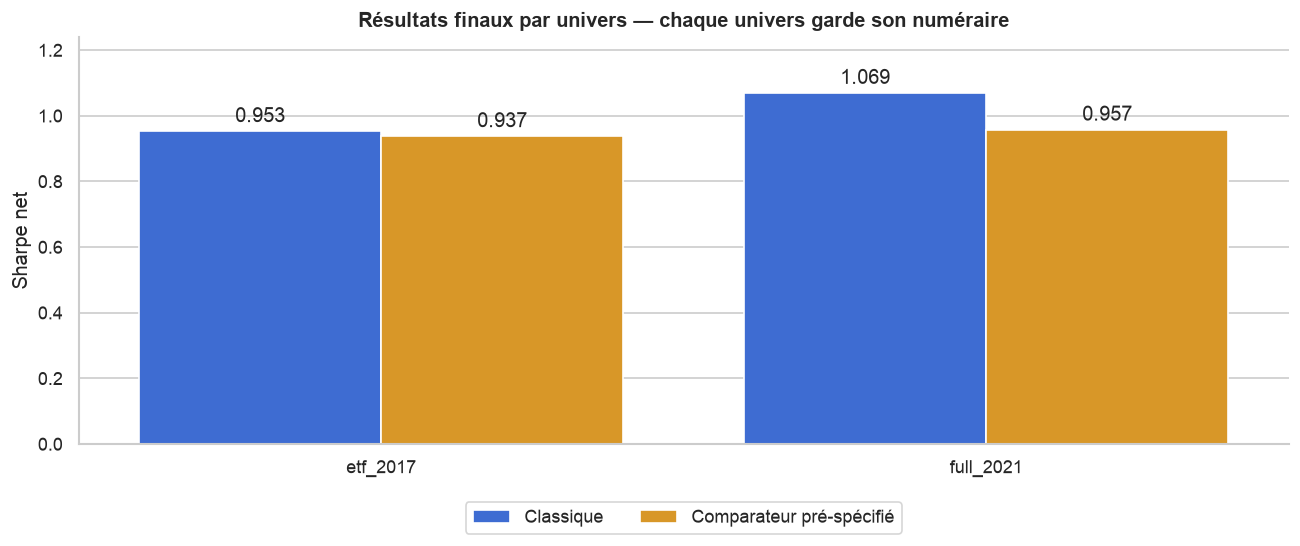

,numéraire,meilleur classique,Sharpe classique,Sharpe régime,écart observé (%)
univers,,,,,
etf_2017,USD,min_variance_lw,0.9525,0.9371,-1.62
full_2021,MAD,max_sharpe,1.0690,0.9571,-10.47


In [4]:
rows = []
for universe, result in showcase["universes"].items():
    classical = result["best_classical"]
    regime = result["strategies"]["regime_conditional"]
    rows.extend([
        {"univers": universe, "approche": classical["name"], "Sharpe net": classical["sharpe_net"], "famille": "Classique"},
        {"univers": universe, "approche": "regime_conditional", "Sharpe net": regime["sharpe_net"], "famille": "Comparateur pré-spécifié"},
    ])
comparison = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.barplot(data=comparison, x="univers", y="Sharpe net", hue="famille", palette=["#2563eb", "#f59e0b"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
ax.set_title("Résultats finaux par univers — chaque univers garde son numéraire")
ax.set_xlabel("")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.set_ylim(0, comparison["Sharpe net"].max() * 1.16)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

summary_rows = []
for universe, result in showcase["universes"].items():
    summary_rows.append({
        "univers": universe,
        "numéraire": currency["universes"][universe]["base_currency"],
        "meilleur classique": result["best_classical"]["name"],
        "Sharpe classique": result["best_classical"]["sharpe_net"],
        "Sharpe régime": result["strategies"]["regime_conditional"]["sharpe_net"],
        "écart observé (%)": result["headline_lift_pct"],
    })
summary = pd.DataFrame(summary_rows).set_index("univers")
display(summary.style.format({"Sharpe classique": "{:.4f}", "Sharpe régime": "{:.4f}", "écart observé (%)": "{:+.2f}"}))

In [5]:
full = summary.loc["full_2021"]
etf = summary.loc["etf_2017"]
display(Markdown(f"""
### Ce que cette correction établit

- `full_2021` est valorisé en **{full['numéraire']}**, sans couverture de change, à partir du taux officiel BAM.
- Son écart ponctuel est **{full['écart observé (%)']:+.2f} %** : {full['Sharpe régime']:.4f} pour `regime_conditional` contre {full['Sharpe classique']:.4f} pour `{full['meilleur classique']}`.
- `etf_2017` reste un univers homogène en **{etf['numéraire']}** et son écart ponctuel est **{etf['écart observé (%)']:+.2f} %**.

### Ce que cela n'établit pas

- Ces écarts descriptifs ne constituent pas un test pairé entre `regime_conditional` et le meilleur classique.
- Les Sharpe des deux univers ne doivent pas être comparés comme s'ils décrivaient le même portefeuille, la même période ou le même numéraire.
- Le prototype n'exécute aucune couverture FX et ne constitue pas un conseil d'investissement.
"""))


### Ce que cette correction établit

- `full_2021` est valorisé en **MAD**, sans couverture de change, à partir du taux officiel BAM.
- Son écart ponctuel est **-10.47 %** : 0.9571 pour `regime_conditional` contre 1.0690 pour `max_sharpe`.
- `etf_2017` reste un univers homogène en **USD** et son écart ponctuel est **-1.62 %**.

### Ce que cela n'établit pas

- Ces écarts descriptifs ne constituent pas un test pairé entre `regime_conditional` et le meilleur classique.
- Les Sharpe des deux univers ne doivent pas être comparés comme s'ils décrivaient le même portefeuille, la même période ou le même numéraire.
- Le prototype n'exécute aucune couverture FX et ne constitue pas un conseil d'investissement.
